# Autoencoder

In [39]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

## WRAPPER FUNCTIONS

In [40]:
def fully_connected(input_tensor, output_nodes,
                    activation=None, seed=None,
                    name='fully_connected'):

    with tf.name_scope(name):
        input_nodes = input_tensor.get_shape().as_list()[1]
        weights = tf.Variable(tf.truncated_normal(shape=(input_nodes,
                                                         output_nodes),
                                                  mean=0.0,
                                                  stddev=0.1,
                                                  dtype=tf.float32,
                                                  seed=seed),
                              name='weights')
        biases = tf.Variable(tf.zeros(shape=[output_nodes]), name='biases')

        act = tf.matmul(input_tensor, weights) + biases
        if activation is not None:
            act = activation(act)
        return act

## DATASET

In [42]:
# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test:", x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


## SETTINGS

In [43]:
# Hyperparameters
learning_rate = 0.01
training_epochs = 5
batch_size = 128

# Architecture
hidden_size = 32
input_size = 784
image_width = 28

# Other
print_interval = 200
random_seed = 123

## GRAPH DEFINITION

In [57]:
import tensorflow as tf

tf.compat.v1.disable_eager_execution()

g = tf.Graph()
with g.as_default():
    tf.compat.v1.set_random_seed(random_seed)

    # Input
    input_layer = tf.compat.v1.placeholder(tf.float32, [None, input_size],
                                           name='input')

    # Encoder
    hidden_layer = tf.compat.v1.keras.layers.Dense(hidden_size,
                                                   activation=tf.nn.relu,
                                                   name='encoding')(input_layer)

    # Decoder
    logits = tf.compat.v1.keras.layers.Dense(input_size,
                                             activation=None,
                                             name='logits')(hidden_layer)

    # Output
    out_layer = tf.nn.sigmoid(logits, name='decoding')

    # Loss
    cost = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
    labels=input_layer, logits=logits), name='cost')
    
    # Optimizer
    optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate)
    train = optimizer.minimize(cost, name='train')


    


    # Saver
    saver = tf.compat.v1.train.Saver()

## TRAINING & EVALUATION

In [58]:
import numpy as np

with tf.compat.v1.Session(graph=g) as sess:
    sess.run(tf.compat.v1.global_variables_initializer())
    np.random.seed(random_seed)

    for epoch in range(training_epochs):
        avg_cost = 0.
        total_batch = num_examples // batch_size

        for i in range(total_batch):
            batch_x, _ = next_batch(batch_size)
            #_, c = sess.run(['train', 'cost:0'], feed_dict={'input:0': batch_x})
            _, c = sess.run([train, cost], feed_dict={input_layer: batch_x})
            avg_cost += c

            if not i % print_interval:
                print("Epoch %02d Minibatch %03d | Cost: %.4f" % (epoch+1, i+1, c))

        print("Epoch %02d | AvgCost: %.4f" % (epoch+1, avg_cost / total_batch))

    # Save model
    saver.save(sess, save_path='./autoencoder.ckpt')
    print("Model saved at ./autoencoder.ckpt")

I0000 00:00:1759141476.532237      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15405 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 01 Minibatch 001 | Cost: 0.6950
Epoch 01 Minibatch 101 | Cost: 0.0969
Epoch 01 Minibatch 201 | Cost: 0.0774
Epoch 01 | AvgCost: 0.1139
Epoch 02 Minibatch 001 | Cost: 0.0754
Epoch 02 Minibatch 101 | Cost: 0.0740
Epoch 02 Minibatch 201 | Cost: 0.0686
Epoch 02 | AvgCost: 0.0725
Epoch 03 Minibatch 001 | Cost: 0.0679
Epoch 03 Minibatch 101 | Cost: 0.0682
Epoch 03 Minibatch 201 | Cost: 0.0677
Epoch 03 | AvgCost: 0.0691
Epoch 04 Minibatch 001 | Cost: 0.0689
Epoch 04 Minibatch 101 | Cost: 0.0670
Epoch 04 Minibatch 201 | Cost: 0.0676
Epoch 04 | AvgCost: 0.0678
Epoch 05 Minibatch 001 | Cost: 0.0673
Epoch 05 Minibatch 101 | Cost: 0.0669
Epoch 05 Minibatch 201 | Cost: 0.0674
Epoch 05 | AvgCost: 0.0671
Epoch 06 Minibatch 001 | Cost: 0.0671
Epoch 06 Minibatch 101 | Cost: 0.0677
Epoch 06 Minibatch 201 | Cost: 0.0671
Epoch 06 | AvgCost: 0.0667
Epoch 07 Minibatch 001 | Cost: 0.0653
Epoch 07 Minibatch 101 | Cost: 0.0680
Epoch 07 Minibatch 201 | Cost: 0.0651
Epoch 07 | AvgCost: 0.0664
Epoch 08 Mini

## VISUALIZATION

I0000 00:00:1759141572.033379      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15405 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


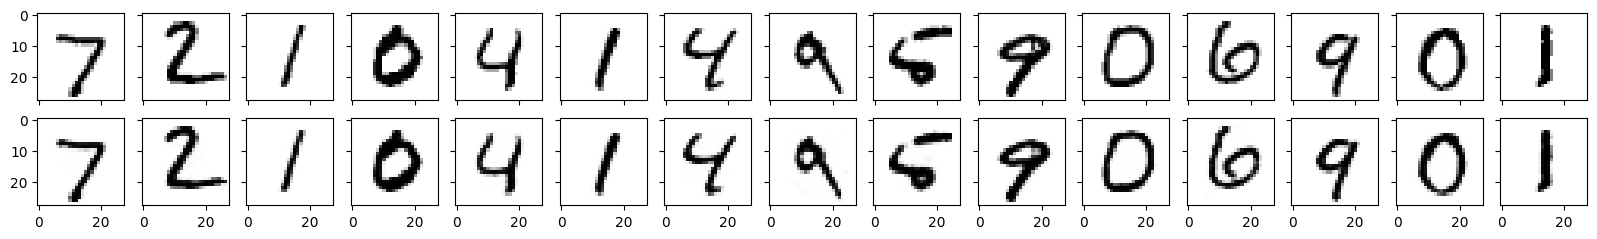

In [61]:
import matplotlib.pyplot as plt

n_images = 15

fig, axes = plt.subplots(nrows=2, ncols=n_images, 
                         sharex=True, sharey=True, figsize=(20, 2.5))
test_images = x_test[:n_images]

with tf.compat.v1.Session(graph=g) as sess:
    saver.restore(sess, save_path='./autoencoder.ckpt')
    decoded = sess.run('decoding:0', feed_dict={'input:0': test_images})

for i in range(n_images):
    for ax, img in zip(axes, [test_images, decoded]):
        ax[i].imshow(img[i].reshape((image_width, image_width)), cmap='binary')
